In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("..\\data\\yield_df_cleaned.csv")
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [4]:
df.select_dtypes(include='number').columns

Index(['Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [5]:
features = df[['hg/ha_yield', 'average_rain_fall_mm_per_year','avg_temp']].copy()
features.head()

,hg/ha_yield,average_rain_fall_mm_per_year,avg_temp
0,36613,1485.0,16.37
1,66667,1485.0,16.37
2,23333,1485.0,16.37
3,12500,1485.0,16.37
4,7000,1485.0,16.37


In [6]:
features.duplicated().sum()

np.int64(33)

In [7]:
features.drop_duplicates(inplace=True)

In [8]:
features.duplicated().sum()

np.int64(0)

In [9]:
features.nunique()

hg/ha_yield                      11514
average_rain_fall_mm_per_year      100
avg_temp                          1831
dtype: int64

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [11]:
scaled_features.shape

(25899, 3)

In [12]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i,random_state=42)
    km.fit(scaled_features)
    wcss.append(km.inertia_)

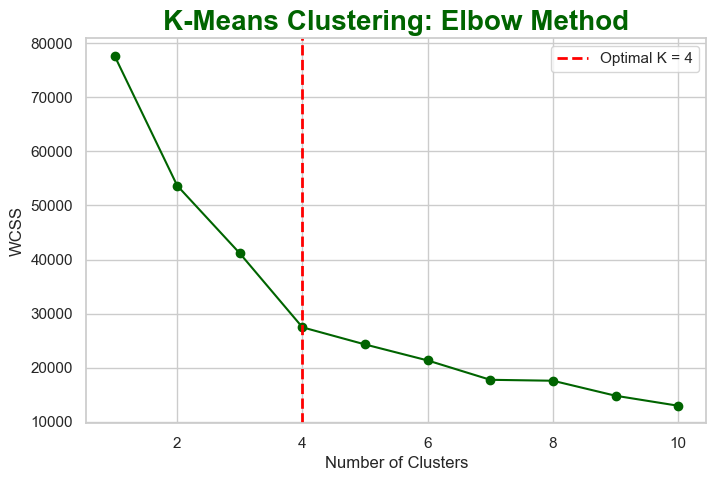

In [33]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o',color='darkgreen')
plt.axvline(x=4,color='red',linestyle='--',linewidth=2,label='Optimal K = 4')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.legend()
plt.title('K-Means Clustering: Elbow Method',fontsize=20,color='darkgreen',fontweight='bold')
plt.show()

In [15]:
kmeans = KMeans(n_clusters=4,random_state=42)
clusters = kmeans.fit_predict(scaled_features)

In [16]:
kmeans.inertia_

27453.844486914113

In [17]:
features['Cluster'] = clusters
features

,hg/ha_yield,average_rain_fall_mm_per_year,avg_temp,Cluster
0,36613,1485.0,16.37,1
1,66667,1485.0,16.37,1
2,23333,1485.0,16.37,1
3,12500,1485.0,16.37,1
4,7000,1485.0,16.37,1
...,...,...,...,...
25927,22581,657.0,19.76,2
25928,3066,657.0,19.76,2
25929,13142,657.0,19.76,2
25930,22222,657.0,19.76,2


In [18]:
features['Cluster'].value_counts()

Cluster
2    9403
1    6493
0    6366
3    3637
Name: count, dtype: int64

In [19]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features,clusters)

print(score)

0.35065118553748814


In [20]:
# scores = []

# for k in range(2, 11):
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     labels = kmeans.fit_predict(scaled_features)

#     score = silhouette_score(scaled_features, labels)
#     scores.append(score)

#     print(f"K={k}: {score:.4f}")

In [21]:
cluster_summary = features.groupby('Cluster')[['hg/ha_yield', 'average_rain_fall_mm_per_year','avg_temp']].mean()
cluster_summary

,hg/ha_yield,average_rain_fall_mm_per_year,avg_temp
Cluster,,,
0,64538.956645,2138.270500,24.453786
1,52397.436932,798.037117,12.140434
2,35836.397958,800.950867,23.873621
3,249282.691779,928.099808,19.222571


In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

In [23]:
pca_df = pd.DataFrame({
    'PCA1': pca_features[:, 0],
    'PCA2': pca_features[:, 1],
    'Cluster': features['Cluster']
})

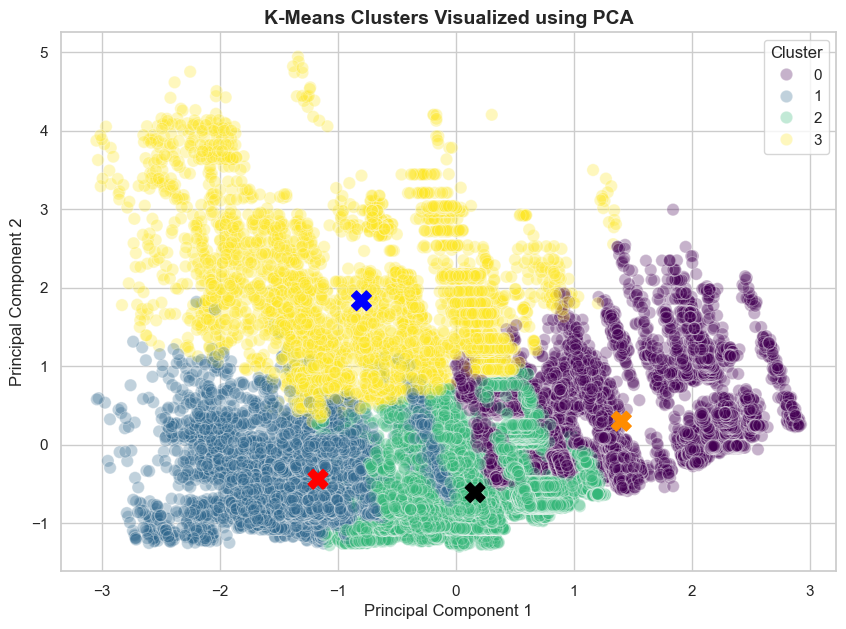

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="GnBu")
plt.figure(figsize=(10, 7))

sns.scatterplot(data=pca_df,x='PCA1',y='PCA2',hue='Cluster',palette='viridis',s=80,alpha=0.3)

plt.title('K-Means Clusters Visualized using PCA',fontweight='bold',fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0],centers[:,1],c=['darkorange','red','black','blue'],s=200,marker='X',label='Centroids')

plt.show()

In [25]:
import plotly.express as px

fig = px.scatter_3d(
    features,
    x='average_rain_fall_mm_per_year',
    y='avg_temp',
    z='hg/ha_yield',
    color='Cluster',
    title='K-Means Clusters',
    labels={
        'average_rain_fall_mm_per_year': 'Rainfall (mm)',
        'avg_temp': 'Temperature (°C)',
        'hg/ha_yield': 'Yield (hg/ha)'
    },
    opacity=0.7,
    color_continuous_scale='Viridis'
)

fig.update_traces(marker=dict(size=4))

fig.show()